# Phase 3: Data Visualization

First, we set up the environment with the necessary libraries:

In [1]:
# Libraries for data processing:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None) # To be able to see all columns from the data frames

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_flights = pd.read_csv("clean-data/customer-flight-activity-clean.csv")
df_customers = pd.read_csv("clean-data/customer-loyal-history-clean.csv")
df_master = pd.read_csv("clean-data/merged-master-data-clean.csv")
df_merged_high_salaries = pd.read_csv("clean-data/merged-high-salaries-clean.csv")
df_flights_booked = pd.read_csv("clean-data/flights-booked-not-zero.csv")

### 1. How is the distribution of flights booked per month during the year?

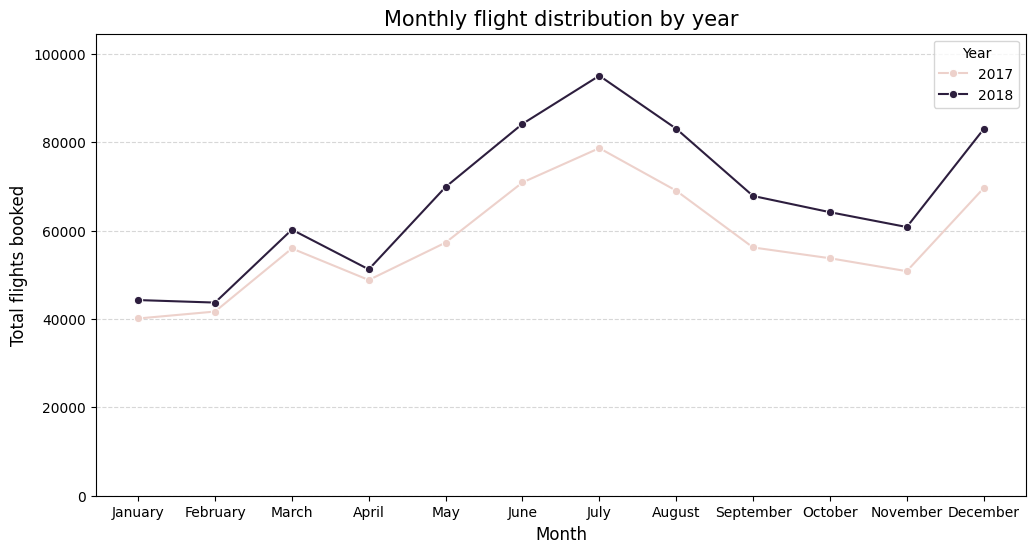

In [3]:
# We need to use a lineplot (tipically used for temopral variables)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# We make sure the 'month' column is categorical and ordered
df_master['month'] = pd.Categorical(df_master['month'], categories=month_order, ordered=True)

# We count flights per year and month
# We reset_index() to keep year and month as columns for plotting
df_counts = df_master.groupby(['year', 'month'])['flights_booked'].sum().reset_index(name='flight_count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_counts, x='month', y='flight_count', hue='year', marker='o')
plt.ylim(0, df_counts['flight_count'].max() * 1.1)
plt.title('Monthly flight distribution by year', fontsize=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total flights booked', fontsize=12)
plt.legend(title='Year')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold';

ANSWER QUESTION 1:

The lineplot shows that the number of flights per month is higher in 2018 than in 2017. The difference is not huge but this indicates that the business is growing. 

The lineplot also shows a clear seasonal trend. For both, the year always start at their lowest point. We can see a small increase around Easter dates, which may indicate that customers tend to book more flights on Easter versus the first months of the year. 

The highest peak in both years is in July. This implies that the busiest season for the airline is summer. 

After summer the flights booked per month have a slight decrease and there is another peak (less than in summer but still relevant) at the end of the year (Christmas holidays). 

### 2. Is there a relationship between flight distance and the points accumulated by customers?

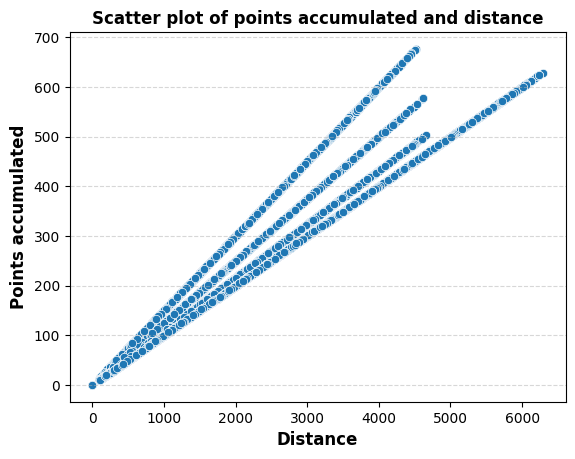

In [4]:
sns.scatterplot(data=df_master, x="distance", y="points_accumulated")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title("Scatter plot of points accumulated and distance")
plt.ylabel('Points accumulated', fontsize=12)
plt.xlabel('Distance', fontsize=12);


ANSWER QUESTION 2:

As we saw in phase 2: There is a strong positive correlation between the points accumulated and the distance.
The meaning of having a strong positive correlation is that as larger is the distance, more points will be accumulated. 

In addition to use a scatter plot to assess the correlation with these two values, we could also have calculated the correlation coefficient or have represented the heatmap as done in phase 2. 

In summary, the distance is a strong factor to accumulate points in this airline. 

### 3. What is the distribution of customers by province or state?

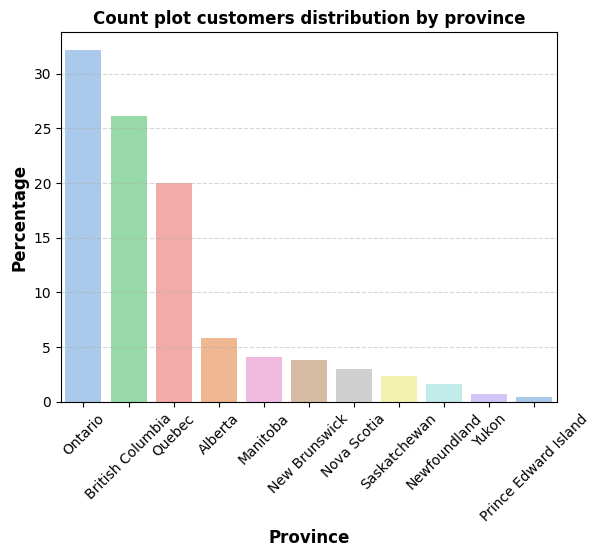

In [5]:
ordered_provinces = df_customers["province"].value_counts().index
sns.countplot(data=df_customers,x="province", stat="percent",order=ordered_provinces,hue="province", palette="pastel")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.title("Count plot customers distribution by province")
plt.ylabel('Percentage', fontsize=12)
plt.xlabel('Province', fontsize=12);

ANSWER QUESTION 3:

We represent the proportion of customers by province with a countplot (it could have been done with a pie but I felt there were too many categories).

Roughly 80% of the customers are either from Quebe, British Columbia or Ontario.

Canada is a big country with most of the population concentrated in both coasts (east and west). The results from the pie were expected since these are the provinces with more population. The rest of the provinces are more rural areas with a less population density.

### 4. How does the average salary compare across the different educational levels of the customers?

In [6]:
mean_salary = round(df_customers["salary"].mean(),2)
median_salary = round(df_customers["salary"].median(),2)

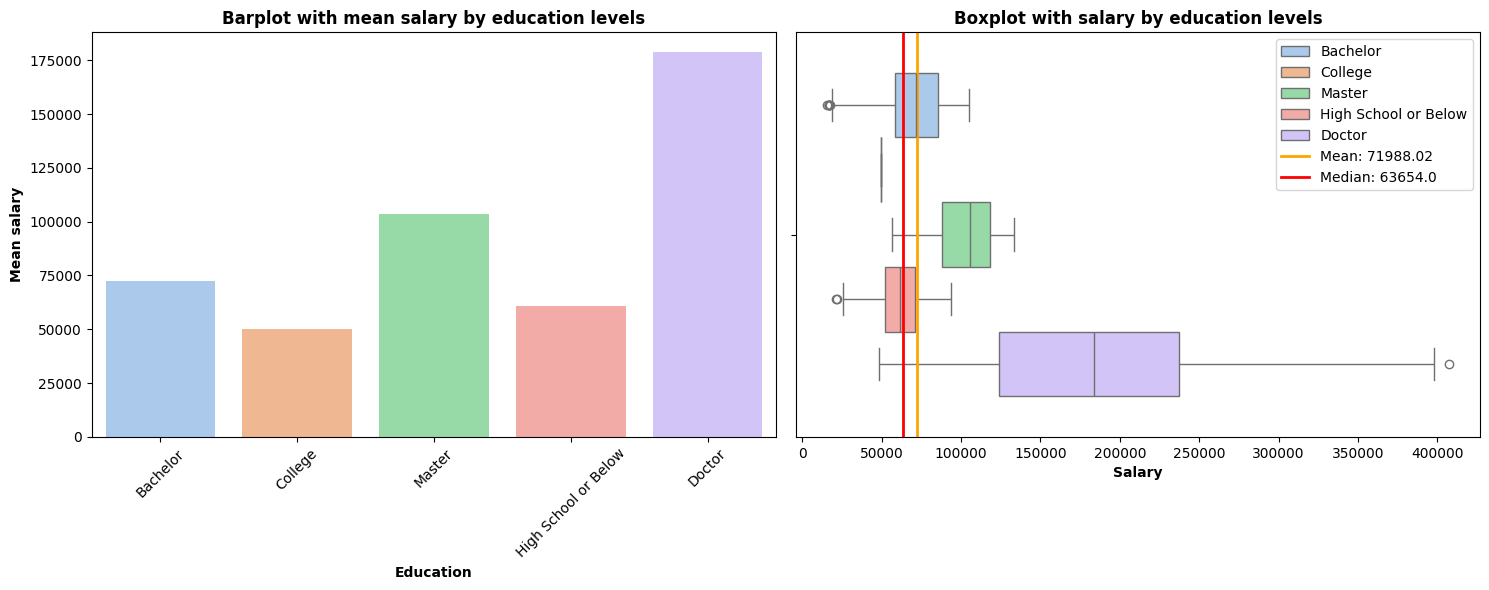

In [7]:
fig, axes = plt.subplots(ncols=2,nrows=1, figsize=(15,6)) 

sns.barplot(data=df_customers, x="education", y = "salary", ax=axes[0],hue="education",palette="pastel",errorbar=None); # barplot in position 0. 

sns.boxplot(data=df_customers, x="salary",ax=axes[1], hue="education",palette="pastel") # boxplot in position 1. 
axes[0].set_title("Barplot with mean salary by education levels")
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_xlabel("Education")
axes[0].set_ylabel("Mean salary")
axes[1].axvline(mean_salary, color = "orange", linestyle = "-", linewidth = 2, label = f"Mean: {mean_salary}")
axes[1].axvline(median_salary, color = "red", linestyle = "-", linewidth = 2, label = f"Median: {median_salary}")
axes[1].legend()
axes[1].set_xlabel("Salary")
axes[1].set_title("Boxplot with salary by education levels")
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.tight_layout();

ANSWER QUESTION 4:

We can clearly see that the average salary (around 175000) for doctors is significantly higher than the other education levels. Followed by the master holders and bachelor. 

The graph on the left is a barplot showing the mean salary on the y axis and the different education levels on the x axis. 

The graph on the right hand side is a boxplot and it gives us a bit more information than the barplot. The line in the middle of the boxes is representing the quartile 50% which is the median. We can clearly see that the median of doctor's salaries is significantly higher than the general mean. 

These higher salaries are influencing the general mean, which is higher than the median.

We can also see that the salaries on the education levels: bachelor, master and high school or below are much narrower than the doctor's one. This means that salaries in these group are more "condensed" and less dispersive than the doctors' salaries.

Last comment: the box for the customers with college as education is so narrow that it is shown as a line. This may be because a large majority of college customers had either negative or null values and we have imputed their values. Probably the imputted values have no dispersion at all and therefore the box is actually a line.


### 5. What is the proportion of customers with different types of loyalty cards?

In [29]:
df_count_cards = df_customers["loyalty_card"].value_counts().reset_index()
df_count_cards

,loyalty_card,count
0,Star,6880
1,Nova,4959
2,Aurora,2939


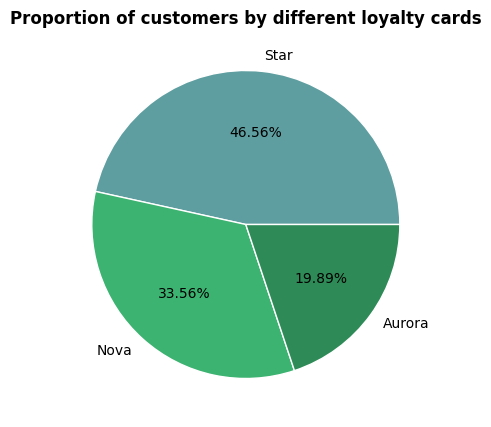

In [30]:
colors = ["cadetblue", "mediumseagreen", "seagreen"]
plt.figure(figsize=(10,5))
plt.pie(data=df_count_cards, x="count", labels="loyalty_card", colors=colors, autopct="%.2f%%", textprops={"fontsize": 10},wedgeprops={'edgecolor': 'white', 'linewidth': 1})
plt.title("Proportion of customers by different loyalty cards");

ANSWER QUESTION 5:

After seeing the pie, the Star card is the leader, representing the largest proportion of the loyalty cards. Nearly half of all customers belong to this loyalty group. 

The Nova card is on second place, and then followed by the Aurora card. I would need to ask the airline what's the rational behing on how they issue these cards. Are the Aurora card holders the ones that flight the most? Are they the ones who more points accumulate? These will be questions to answer on next steps.

### 6. How are customers distributed according to their marital status and gender?

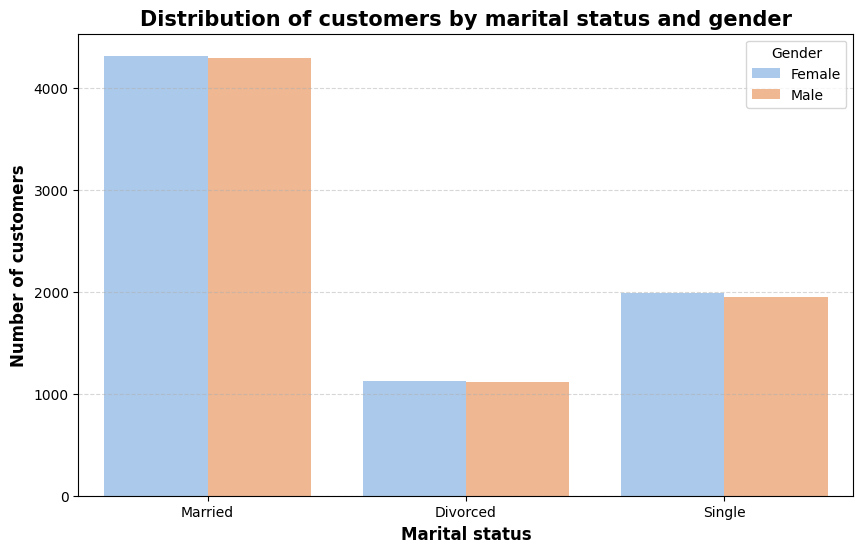

In [40]:
plt.figure(figsize=(10,6))

sns.countplot(data=df_customers, x='marital_status', hue='gender', palette='pastel')

plt.title('Distribution of customers by marital status and gender', fontsize=15,fontweight="bold")
plt.xlabel('Marital status', fontsize=12,fontweight="bold")
plt.ylabel('Number of customers', fontsize=12,fontweight="bold")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Gender');

ANSWER QUESTION 6:

Married customers are the majority, followed by singles and lastly, the divorced.

Both bars, male and female, are almost the same height accross the different marital status, representing a gender balance distribution.

